In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("feature_preprocessing_dataset.csv")

In [3]:
threshold = df["at_risk"].mean()
df["at_risk"] = (df["at_risk"] > threshold).astype(int)


In [4]:
X = df.drop("at_risk", axis=1)
y = df["at_risk"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
knn = KNeighborsClassifier(n_neighbors=5)

In [7]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
y_pred = knn.predict(X_test)

In [9]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[333 540]
 [416 711]]


In [10]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.38      0.41       873
           1       0.57      0.63      0.60      1127

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.52      0.52      2000



In [11]:
cm = confusion_matrix(y_test, y_pred)

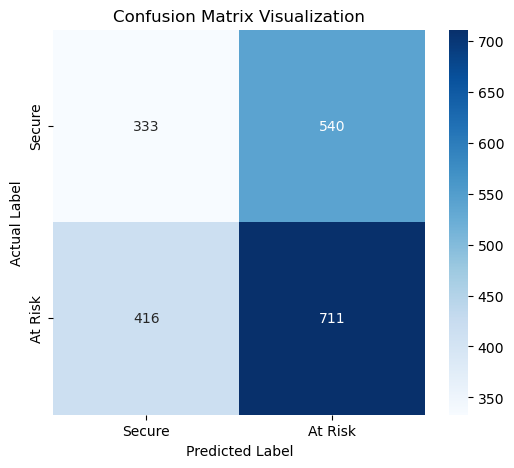

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Secure","At Risk"],
            yticklabels=["Secure","At Risk"])

plt.title("Confusion Matrix Visualization")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()